In [26]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from IPython.display import Image
from dotenv import load_dotenv
import os

load_dotenv()

True

In [27]:
GROQ_API_KEY=os.getenv("GROQ_API_KEY")
GROQ_MODEL=os.getenv("GROQ_MODEL")

In [28]:
model = ChatGroq(model=GROQ_MODEL, api_key=GROQ_API_KEY)

In [29]:
# define state
class BlogState(TypedDict):
    title: str
    outline: str
    blog: str
    score: int

In [30]:
def create_outline(state: BlogState) -> BlogState:
    title = state['title']
    
    # Using a more descriptive prompt to get a structured response
    prompt = f"""
    Act as an expert content strategist. Create a comprehensive, SEO-optimized outline for a blog post titled: "{title}".
    
    The outline must include:
    - An Introduction (with a hook and thesis statement)
    - 3 to 5 Main Body sections (H2) with sub-points (H3)
    - A Conclusion with a Call to Action (CTA)
    
    Format the output using clear Markdown headings.
    """
    
    # Call the model
    response = model.invoke(prompt).content
    
    # Update the state with the generated outline
    state['outline'] = response
    
    return state


In [31]:
def create_blog(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']
    
    # Prompting for flow and professional formatting
    prompt = f"""
    Write a high-quality, engaging blog post based on the title and outline below.
    
    TITLE: {title}
    OUTLINE: 
    {outline}
    
    INSTRUCTIONS:
    - Use a professional yet conversational tone.
    - Use Markdown for bolding, bullet points, and headers (H2, H3).
    - Ensure smooth transitions between the sections defined in the outline.
    - Do not include meta-commentary like "Sure, here is your blog." Start directly with the content.
    """
    
    # Generate the blog content
    response = model.invoke(prompt).content
    
    # Update state
    state['blog'] = response
    
    return state


In [32]:
def blog_score(state: BlogState) -> BlogState:
    outline = state['outline']
    blog = state['blog']
    
    # Using a structured prompt for better accuracy
    prompt = f"""
    You are a professional content editor. Evaluate the blog post below against the provided outline.
    
    OUTLINE:
    {outline}
    
    BLOG CONTENT:
    {blog}
    
    SCORING CRITERIA:
    1. Adherence: Does the blog cover all points in the outline?
    2. Quality: Is the writing engaging and clear?
    3. Formatting: Are H2/H3 tags used correctly as per the outline?
    
    Provide a single integer score from 1 to 100 where 100 is perfect. 
    Respond ONLY with the integer.
    """
    
    # Invoke the model and clean the output to ensure it's an integer
    response = model.invoke(prompt).content
    try:
        # Extract only the digits in case the model adds extra text
        blog_score = int(''.join(filter(str.isdigit, response)))
    except ValueError:
        blog_score = 0  # Fallback error score
    
    state['score'] = blog_score
    return state


In [33]:
# define graph
graph = StateGraph(BlogState)

# add node to the graph
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('blog_score', blog_score)

# add edges to the node
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', 'blog_score')
graph.add_edge('blog_score', END)

# compile the graph
workflow = graph.compile()

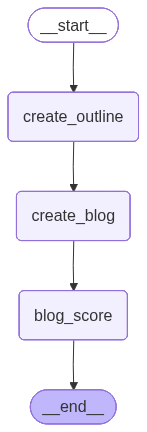

In [34]:
Image(workflow.get_graph().draw_mermaid_png())

In [35]:
initial_state = {'title': 'Rise of Agentic AI'}

# execute the workflow
final_state = workflow.invoke(initial_state)

print(final_state)

{'title': 'Rise of Agentic AI', 'outline': '## **Outline: “Rise of Agentic AI” – A Deep‑Dive SEO‑Optimized Blog Post**\n\n---\n\n### **Introduction**\n**Hook:**  \n*“Imagine a world where software doesn’t just follow instructions—it decides what to do next, learns on its own, and even sets its own goals.”*  \n\n**Thesis Statement:**  \nThe emergence of **agentic AI**—autonomous, goal‑driven artificial intelligence—marks a paradigm shift in technology, ethics, and industry, demanding a fresh look at its capabilities, real‑world applications, and the societal implications that accompany this newfound agency.\n\n*Target SEO Keywords:* rise of agentic AI, what is agentic AI, autonomous AI, AI agents, future of AI, AI agency, AI ethics  \n\n---\n\n## **1. What Is Agentic AI?**  *(H2)*\n#### 1.1 Definition & Core Characteristics *(H3)*\n- Autonomy, self‑directed goal formation, and adaptive decision‑making  \n- Contrast with “tool‑oriented” AI (e.g., classifiers, chatbots)  \n\n#### 1.2 Hist

In [36]:
print(final_state['outline'])

## **Outline: “Rise of Agentic AI” – A Deep‑Dive SEO‑Optimized Blog Post**

---

### **Introduction**
**Hook:**  
*“Imagine a world where software doesn’t just follow instructions—it decides what to do next, learns on its own, and even sets its own goals.”*  

**Thesis Statement:**  
The emergence of **agentic AI**—autonomous, goal‑driven artificial intelligence—marks a paradigm shift in technology, ethics, and industry, demanding a fresh look at its capabilities, real‑world applications, and the societal implications that accompany this newfound agency.

*Target SEO Keywords:* rise of agentic AI, what is agentic AI, autonomous AI, AI agents, future of AI, AI agency, AI ethics  

---

## **1. What Is Agentic AI?**  *(H2)*
#### 1.1 Definition & Core Characteristics *(H3)*
- Autonomy, self‑directed goal formation, and adaptive decision‑making  
- Contrast with “tool‑oriented” AI (e.g., classifiers, chatbots)  

#### 1.2 Historical Milestones *(H3)*
- Early reinforcement‑learning agents (

In [37]:
print(final_state['blog'])

## Rise of Agentic AI

### Introduction  
**Hook:** *“Imagine a world where software doesn’t just follow instructions—it decides what to do next, learns on its own, and even sets its own goals.”*  

**Thesis:** The emergence of **agentic AI**—autonomous, goal‑driven artificial intelligence—marks a paradigm shift in technology, ethics, and industry. It compels us to rethink what AI can achieve, how it’s applied today, and the societal responsibilities that come with giving machines agency.

*Target SEO Keywords:* **rise of agentic AI**, **what is agentic AI**, **autonomous AI**, **AI agents**, **future of AI**, **AI agency**, **AI ethics**  

---

## 1. What Is Agentic AI?  

### 1.1 Definition & Core Characteristics  
Agentic AI refers to systems that possess **autonomy**, can **form self‑directed goals**, and make **adaptive decisions** without constant human prompting. Unlike traditional, tool‑oriented AI (e.g., classifiers, single‑turn chatbots), an agentic model:

- **Plans** multi

In [38]:
print(final_state['score'])

92
